In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import os
from scipy.signal import savgol_filter, find_peaks
from scipy import constants, interpolate, signal, optimize
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
# from astropy import units as u
from scipy.signal import savgol_filter
# import pyLPD.MLtools as mlt
#import MLtools as mlt
import re
from scipy.signal import savgol_filter, lfilter
from PIL import Image

π = constants.pi
c = constants.c

rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
rcParams['font.size'] = '24'
rcParams['font.style'] = 'normal'
rcParams['font.weight'] = 'medium'
rcParams['pdf.fonttype'] = '42'

rcParams['grid.linestyle'] = ':'
rcParams['grid.linewidth'] = 1
rcParams['grid.alpha'] = 0.75

rcParams['lines.linewidth'] = 3

rcParams['axes.xmargin'] = 0
rcParams['axes.ymargin'] = 0
rcParams['axes.axisbelow'] = True

rcParams['xtick.direction'] = 'out'
rcParams['ytick.direction'] = 'out'
rcParams['xtick.major.size'] = 7
rcParams['xtick.major.width'] = 1
rcParams['xtick.minor.size'] = 3.5
rcParams['xtick.minor.width'] = 1
rcParams['ytick.major.size'] = 7
rcParams['ytick.major.width'] = 1

rcParams["figure.frameon"] = False
rcParams["figure.figsize"] = (16,16)
rcParams["figure.dpi"] = 70

rcParams['text.usetex'] = False

# rcParams["figure.figsize"] = [6.4, 4.8]
# rcParams['figure.autolayout'] = True

def cm2inch(*tupl):
    inch = 2.54
    if isinstance(tupl[0], tuple):
        return tuple(i/inch for i in tupl[0])
    else:
        return tuple(i/inch for i in tupl)

In [4]:
# data = pd.read_csv("G  .shortcut-targets-by-id 0B-cdi4XK3uCzaTA4dHBYZkx5ZWs LPD Team uploads Miguel Nienstedt Numerical Data depleted_3_modes_d2=0_s=1.56_dr=3.6.csv")

folder_path = "/home/eduardo/Documents/Ciencia/UNICAMP/[Proj]onChipOPO/Calculations_new/r-2r-r-molecule/notebooks/testjl/"

data = pd.read_csv(folder_path + "depleted_3_modes_d2=0_s=1.4_dr=3.2_lots.csv")

def julia_str_to_complex(s):
    s = s.strip().replace("im", "j")        # Replace 'im' with Python-style 'j'
    s = re.sub(r'\s+', '', s)               # Remove all whitespace
    return complex(s)

Text(0.5, 0, 'Detuning (a.u.)')

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

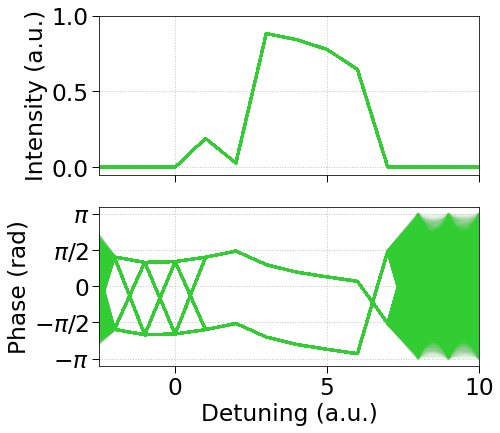

In [5]:
f, ax = plt.subplots(2,1,sharex=1, figsize = (7,6.5))

interations = len(np.unique(data['Iteration']))
interation_size = int(len(data)/interations)
for ind, interation in enumerate(range(interations)[:]):
    data_int = data[ind*interation_size:ind*interation_size+interation_size]

    a_n1 = data_int['a_n1'].apply(julia_str_to_complex)
    a0 = data_int['a0'].apply(julia_str_to_complex)
    a1 = data_int['a1'].apply(julia_str_to_complex)

    # ax[0].plot(data_int['Δ'], np.abs(a_n1)**2, color = 'red')
    ax[0].plot(data_int['Δ'], np.abs(a0)**2, color = 'limegreen', alpha = .01)
    # ax[0].plot(data_int['Δ'], np.abs(a1)**2, color = 'b')

    # ax[1].plot(data_int['Δ'], np.angle(a_n1), color = 'red')
    ax[1].plot(data_int['Δ'], np.angle(a0), color = 'limegreen', alpha = .01)
    # ax[1].plot(data_int['Δ'], np.angle(a1), color = 'b')

ax[0].set_ylim(-.05, 1)
ax[0].grid()
ax[1].grid()
plt.xlim(-2.5, 10)
ax[0].set_xticks([0,5,10])

yticks = [-np.pi, -np.pi/2, 0, np.pi/2, np.pi]
ax[1].set_yticks(yticks)
ax[1].set_yticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"])
ax[1].set_ylim(-(1.1)*np.pi, (1.1)*np.pi)

ax[0].set_ylabel('Intensity (a.u.)')
ax[1].set_ylabel('Phase (rad)')
ax[1].set_xlabel('Detuning (a.u.)')

# plt.tight_layout()

# plt.savefig('intensity and phase.pdf')

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


(0, 0)
(0, 1)
(1, 0)
(1, 1)


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

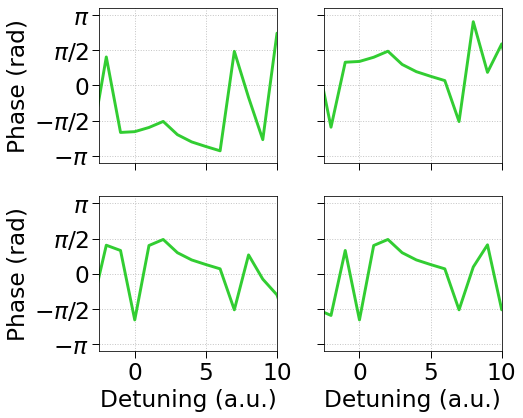

In [6]:
f, ax = plt.subplots(2, 2, sharex=1, sharey= 1, figsize = (8,6.5))

interations = len(np.unique(data['Iteration']))
interation_size = int(len(data)/interations)

cases = [0, 5, 9, 10]
plotinds = [(0,0), (0,1), (1,0), (1,1)]
plotind = 0


for ind, interation in enumerate(range(interations)):
    
    if ind in cases:
    
        data_int = data[ind*interation_size:ind*interation_size+interation_size]

        a_n1 = data_int['a_n1'].apply(julia_str_to_complex)
        a0 = data_int['a0'].apply(julia_str_to_complex)
        a1 = data_int['a1'].apply(julia_str_to_complex)

        ax[plotinds[plotind]].plot(data_int['Δ'], np.angle(a0), color = 'limegreen', alpha = 1)
        print(plotinds[plotind])

        plotind += 1

# ax[0].set_ylim(-.05, 1)
# ax[0].grid()
# ax[1].grid()
plt.xlim(-2.5, 10)

yticks = [-np.pi, -np.pi/2, 0, np.pi/2, np.pi]
ax[0,0].set_yticks(yticks)
ax[0,0].set_yticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"])
ax[1,0].set_yticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"])
ax[1,0].set_ylim(-(1.1)*np.pi, (1.1)*np.pi)

ax[0,0].set_xticks([0,5,10])

# ax[0].set_ylabel('Intensity (a.u.)')
ax[0,0].set_ylabel('Phase (rad)')
ax[1,0].set_ylabel('Phase (rad)')
ax[1,0].set_xlabel('Detuning (a.u.)')
ax[1,1].set_xlabel('Detuning (a.u.)')

ax[0,0].grid()
ax[0,1].grid()
ax[1,0].grid()
ax[1,1].grid()

plt.tight_layout()

plt.savefig('cases.pdf')

In [7]:
delta_cut_1 = 1.5
delta_cut_2 = 4.8

angles_0_1 = np.angle(data['a0'].apply(julia_str_to_complex))[data['Δ'] == delta_cut_1]
angles_0_2  = np.angle(data['a0'].apply(julia_str_to_complex))[data['Δ'] == delta_cut_2]

In [8]:
case_1 = 0
case_2 = 0
case_3 = 0
case_4 = 0
# error = 0

for i in range(len(angles_0_1)):
    phase_1 = angles_0_1[i]
    phase_2 = angles_0_2[i]

    if phase_1 > 0 and phase_2 > 0:
        case_4 = case_4+1
    elif phase_1 > 0 and phase_2 < 0:
        case_3 = case_3+1
    elif phase_1 < 0 and phase_2 > 0:
        case_2 = case_2+1
    elif phase_1 < 0 and phase_2 < 0:
        case_1 = case_1+1
    # else:
    #     error = error+1


print(case_1, case_2, case_3, case_4)

0 0 0 0


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

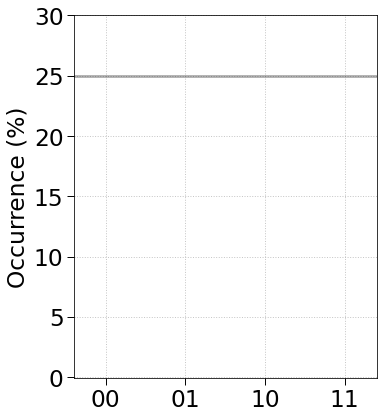

In [9]:
values = np.array([case_1, case_2, case_3, case_4])/10
labels = ["00", "01", "10", "11"]

fig = plt.figure(figsize=(6,6.5))

plt.bar(labels, values)

plt.ylabel("Occurrence (%)")
plt.ylim(top = 30)

plt.yticks([0, 5, 10, 15, 20, 25, 30])

plt.axhline(25, color = 'k', alpha = .3)

plt.grid()

plt.tight_layout()
plt.savefig('histogram.pdf')

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

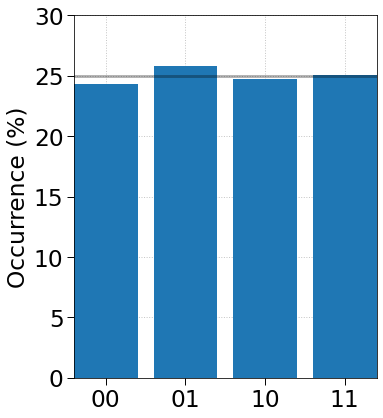

In [10]:
values = np.array([2434, 2583, 2477, 2506])/100
labels = ["00", "01", "10", "11"]

fig = plt.figure(figsize=(6,6.5))

plt.bar(labels, values)

plt.ylabel("Occurrence (%)")
plt.ylim(top = 30)

plt.yticks([0, 5, 10, 15, 20, 25, 30])

plt.axhline(25, color = 'k', alpha = .3)

plt.grid()

plt.tight_layout()
plt.savefig('histogram.pdf')